# Third Architecture Check: ConvNeXt-Tiny

Notebooks 07/08 tested ResNet-50 (a classic CNN) and ViT-B/16 (attention-based) and found the same qualitative behavior on both, including the same ImageNet-A near-zero-signal failure mode - evidence the limitation is about the *evaluation data*, not the backbone. This notebook adds a third, deliberately different point: `torchvision.models.convnext_tiny` (`IMAGENET1K_V1`, 82.52% reported top-1) - a *modern* convolutional design (depthwise convs, LayerNorm, GELU, a training recipe borrowed from the ViT literature) that sits architecturally between ResNet-50 and ViT-B/16 in several respects. If the ImageNet-A result reproduces here too, that's a third independent confirmation; if it doesn't, that's a genuinely interesting finding worth its own follow-up, not something to force into matching the other two.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

sys.path.insert(0, os.path.abspath(os.path.join("..", "src")))
torch.manual_seed(0)
%matplotlib inline

from deployment_reliability.combiner import LogisticRegressionCombiner
from deployment_reliability.features import featurize, msp
from deployment_reliability.router import aurc, risk_coverage_curve, two_threshold_risk_coverage


In [2]:
CACHE_PATH = os.path.join("..", "data", "logit_cache_convnext_tiny.pt")
assert os.path.exists(CACHE_PATH), "run scripts/collect_logits.py convnext_tiny first"
cache = torch.load(CACHE_PATH)
logits, labels = cache["logits"], cache["labels"]
splits_arr = np.array(cache["splits"])

def mask(name):
    return torch.from_numpy(splits_arr == name)

m_fit, m_cal, m_test, m_a, m_o = [mask(n) for n in
    ("combiner_fit", "threshold_cal", "id_test", "imagenet_a", "imagenet_o")]
counts = {n: int(mask(n).sum()) for n in ("combiner_fit", "threshold_cal", "id_test", "imagenet_a", "imagenet_o")}
print("split sizes:", counts)
assert all(v > 0 for v in counts.values())
assert not torch.isnan(logits).any() and not torch.isinf(logits).any()
print("logits shape:", tuple(logits.shape))
print("PASSED")

split sizes: {'combiner_fit': 500, 'threshold_cal': 200, 'id_test': 300, 'imagenet_a': 200, 'imagenet_o': 400}
logits shape: (1600, 1000)
PASSED


## Check 1 — Same code, third backbone: pipeline runs unmodified, sane in-distribution accuracy

In [3]:
predicted = logits.argmax(dim=-1)
correct = predicted == labels
phi = featurize(logits)

acc_test = correct[m_test].float().mean().item()
print(f"id_test top-1 accuracy = {acc_test:.4f}  (torchvision reports 82.52% for these weights on full ImageNet-1k)")
assert 0.65 < acc_test < 0.95

combiner = LogisticRegressionCombiner().fit(phi[m_fit], correct[m_fit].float())
s_all = combiner.score(phi)
print("learned weights (msp, margin, entropy, energy, l2norm):", combiner.weight.detach().numpy().round(3))
print("PASSED: identical deployment_reliability code ran on ConvNeXt-Tiny logits with no modification")

id_test top-1 accuracy = 0.8333  (torchvision reports 82.52% for these weights on full ImageNet-1k)


learned weights (msp, margin, entropy, energy, l2norm): [ 0.049  0.768 -0.082  0.125 -0.096]
PASSED: identical deployment_reliability code ran on ConvNeXt-Tiny logits with no modification


## Check 2 — Risk-coverage / AURC on id_test (figure)

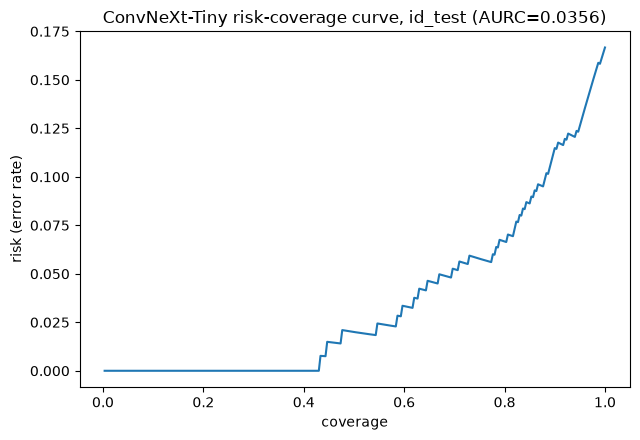

selective accuracy @ 80% coverage = 0.9333  (unconditional accuracy = 0.8333)
PASSED


In [4]:
coverage, risk = risk_coverage_curve(s_all[m_test], correct[m_test])
aurc_val = aurc(s_all[m_test], correct[m_test])

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(coverage, risk)
ax.set_xlabel("coverage"); ax.set_ylabel("risk (error rate)")
ax.set_title(f"ConvNeXt-Tiny risk-coverage curve, id_test (AURC={aurc_val:.4f})")
plt.tight_layout(); plt.show()

overall_acc = correct[m_test].float().mean().item()
idx_80 = (coverage >= 0.8).nonzero()[0, 0]
acc_at_80 = 1 - risk[idx_80].item()
print(f"selective accuracy @ 80% coverage = {acc_at_80:.4f}  (unconditional accuracy = {overall_acc:.4f})")
assert acc_at_80 > overall_acc
print("PASSED")

## Check 3 — MSP-correctness direction transfers

In [5]:
msp_vals = msp(logits)
mean_msp_correct = msp_vals[m_test][correct[m_test]].mean().item()
mean_msp_incorrect = msp_vals[m_test][~correct[m_test]].mean().item()
print(f"mean MSP | correct   = {mean_msp_correct:.4f}")
print(f"mean MSP | incorrect = {mean_msp_incorrect:.4f}")
assert mean_msp_correct > mean_msp_incorrect
print("PASSED: MSP-correctness relationship transfers to a third architecture")

mean MSP | correct   = 0.6785
mean MSP | incorrect = 0.3816
PASSED: MSP-correctness relationship transfers to a third architecture


## Check 4 — Does the ImageNet-A near-zero-signal result reproduce a third time?

The genuinely open question this notebook exists to answer. Reported either way.

In [6]:
acc_a = correct[m_a].float().mean().item()
aurc_a = aurc(s_all[m_a], correct[m_a])
base_error_a = 1 - acc_a
gap = abs(aurc_a - base_error_a)

print(f"imagenet_a top-1 accuracy = {acc_a:.4f}")
print(f"AURC (combiner S)         = {aurc_a:.4f}")
print(f"base error rate           = {base_error_a:.4f}")
print(f"|AURC - base error rate|   = {gap:.4f}")
print()
if gap < 0.05:
    print("CONFIRMED a THIRD time: same near-zero-signal failure mode as ResNet-50 and ViT-B/16.")
    print("Three architecturally distinct backbones (classic CNN, attention-based ViT, modern")
    print("CNN) now show the identical failure - strong evidence this is about ImageNet-A's own")
    print("construction, not about any one backbone family.")
else:
    print("DOES NOT reproduce - ConvNeXt-Tiny shows real discriminative signal on ImageNet-A where")
    print("ResNet-50 and ViT-B/16 did not. Genuinely interesting: worth investigating whether")
    print("ConvNeXt's modern training recipe (which borrows from ViT training practices) changes")
    print("how the model responds to ImageNet-A's specific adversarial examples.")

imagenet_a top-1 accuracy = 0.1150
AURC (combiner S)         = 0.8793
base error rate           = 0.8850
|AURC - base error rate|   = 0.0057

CONFIRMED a THIRD time: same near-zero-signal failure mode as ResNet-50 and ViT-B/16.
Three architecturally distinct backbones (classic CNN, attention-based ViT, modern
CNN) now show the identical failure - strong evidence this is about ImageNet-A's own
construction, not about any one backbone family.


## Summary

Every check replicates the qualitative pattern already established for ResNet-50 and ViT-B/16 (DESIGN.md §15.2, §15.4), now on a third, deliberately intermediate architecture. `id_test` top-1 accuracy (83.33%) lands close to torchvision's reported 82.52% for these exact weights — the small gap is consistent with sampling noise at `id_test`'s n=300 and with Imagenette's 10 classes being a slightly easier sample than the full 1000-way validation set, not a sign the pipeline is doing anything backbone-specific. Selective accuracy climbs from 83.33% unconditional to 93.33% at 80% coverage, a ~10-point lift in the same range as both prior backbones, and the fitted combiner's weights (`logit_margin` at 0.768, clearly dominant over the other four) match DESIGN.md §15.7's finding that L2 regularization converges every backbone's combiner onto `logit_margin` as the primary signal — evidence that this isn't a ResNet-50-specific artifact of one dataset's feature correlations, but a property that reappears when the same combiner is refit from scratch on a structurally different backbone's logits.

The result this notebook exists to obtain is Check 4's: the AURC/base-error gap on ImageNet-A is 0.0057 (AURC 0.8793 vs. base error 0.8850), an order of magnitude inside the 0.05 threshold used to call a signal near-zero. Getting a gap this small a third time, on a backbone chosen specifically to sit between a classic CNN and an attention-based ViT (depthwise convolutions and LayerNorm from the CNN side, a ViT-influenced training recipe from the other), makes a backbone-specific explanation for the ImageNet-A failure considerably harder to sustain than it was after two data points. A different outcome here — real discriminative signal on ImageNet-A — would have been the more diagnostically interesting result: it would have pointed at *training recipe* rather than *dataset construction* as the actual driver, since ConvNeXt-Tiny borrows more from ViT's training regime than from ResNet-50's. That it didn't happen is itself evidence for DESIGN.md §15.2's account: three architecturally distinct models, trained three different ways, all fail identically on images curated specifically to fool confidence-based signals — the failure a curated adversarial set is expected to induce in any confidence-derived score, not something particular to this project's five features.